# Bone Age — Hızlı Test Notebook

Bu notebook yalnızca pipeline testine yöneliktir. Hiçbir dosya, klasör veya model diske yazılmaz. Tüm çıktılar yalnızca notebook içinde gösterilir.

| Parametre | Değer |
|---|---|
| Görüntü sayısı | ~50 |
| Epoch | 5 |
| Görüntü boyutu | 128×128 |
| Model sayısı | 3 |

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.19.0
GPU        : False


---
## Ayarlar ve Veri Yolları

Hiçbir output klasörü oluşturulmaz. Sadece veri okunur.

In [2]:
BASE_DIR      = Path(".").resolve()
DATA_DIR      = BASE_DIR / "data"
TRAIN_CSV     = DATA_DIR / "boneage-training-dataset.csv"
TEST_CSV      = DATA_DIR / "boneage-test-dataset.csv"

def find_image_dir(base):
    candidates = [
        base / "boneage-training-dataset",
        base / "boneage-training-dataset" / "boneage-training-dataset",
        base / "train",
        base / "images",
    ]
    for c in candidates:
        if c.exists() and any(c.glob("*.png")):
            return c
    for p in base.rglob("*.png"):
        return p.parent
    return candidates[0]

TRAIN_IMG_DIR = find_image_dir(DATA_DIR)

SAMPLE_FRAC  = 0.004
EPOCHS       = 5
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 16
RANDOM_STATE = 42
BONEAGE_COL  = "boneage"
GENDER_COL   = "male"

print(f"Veri klasörü  : {TRAIN_IMG_DIR}")
img_count = len(list(TRAIN_IMG_DIR.glob("*.png")))
print(f"PNG sayısı    : {img_count}")
print(f"SAMPLE_FRAC   : {SAMPLE_FRAC} → ~{int(img_count * SAMPLE_FRAC)} görüntü kullanılacak")

Veri klasörü  : C:\Users\Can\Desktop\data\boneage-training-dataset\boneage-training-dataset
PNG sayısı    : 12611
SAMPLE_FRAC   : 0.004 → ~50 görüntü kullanılacak


---
## Veri Yükleme ve Temizleme

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
id_col   = train_df.columns[0]

print(f"CSV boyutu   : {train_df.shape}")
print(f"Sütunlar     : {list(train_df.columns)}")
print(f"Eksik değer  : {train_df.isnull().sum().sum()}")
train_df.head(3)

CSV boyutu   : (12611, 3)
Sütunlar     : ['id', 'boneage', 'male']
Eksik değer  : 0


,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False


In [4]:
def find_image_path(img_id, img_dir):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = img_dir / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

train_df["img_path"] = train_df[id_col].astype(str).apply(
    lambda x: find_image_path(x, TRAIN_IMG_DIR)
)
train_df = train_df.dropna(subset=["img_path"]).reset_index(drop=True)

train_df = train_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Kullanılacak görüntü sayısı : {len(train_df)}")
print(f"Kemik yaşı ort              : {train_df[BONEAGE_COL].mean():.1f} ay")
print(f"Cinsiyet (Erkek oranı)      : %{train_df[GENDER_COL].isin([True,1]).mean()*100:.1f}")

Kullanılacak görüntü sayısı : 50
Kemik yaşı ort              : 114.1 ay
Cinsiyet (Erkek oranı)      : %40.0


---
## Hızlı EDA

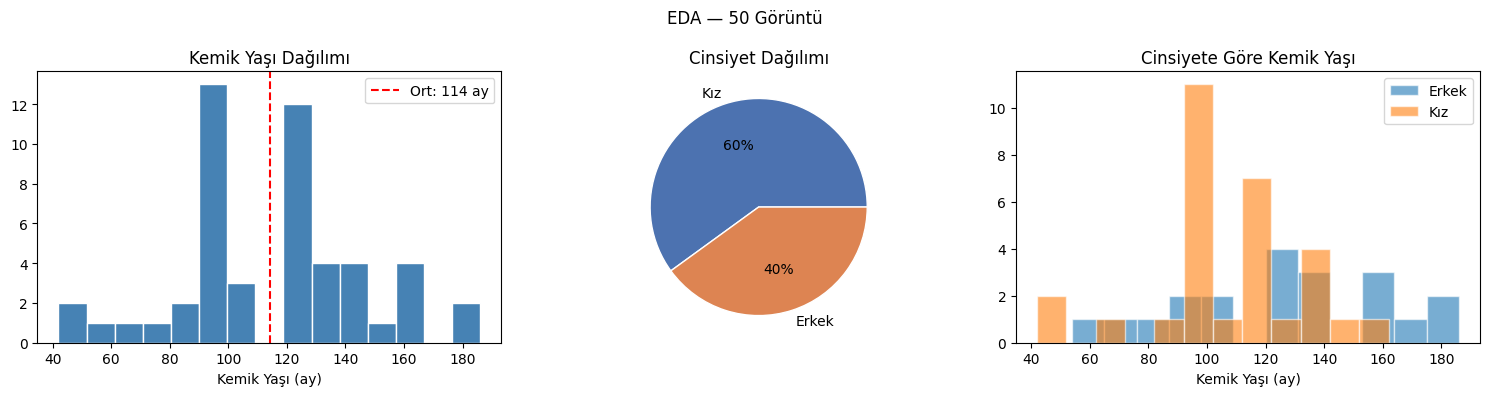

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df[BONEAGE_COL], bins=15, color="steelblue", edgecolor="white")
axes[0].axvline(train_df[BONEAGE_COL].mean(), color="red", linestyle="--",
                label=f"Ort: {train_df[BONEAGE_COL].mean():.0f} ay")
axes[0].set_title("Kemik Yaşı Dağılımı")
axes[0].set_xlabel("Kemik Yaşı (ay)")
axes[0].legend()

gender_labels = train_df[GENDER_COL].map({True: "Erkek", False: "Kız", 1: "Erkek", 0: "Kız"})
gender_counts = gender_labels.value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct="%1.0f%%", colors=["#4C72B0", "#DD8452"],
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Cinsiyet Dağılımı")

for label, grp in train_df.groupby(gender_labels):
    axes[2].hist(grp[BONEAGE_COL], bins=12, alpha=0.6, label=label, edgecolor="white")
axes[2].set_title("Cinsiyete Göre Kemik Yaşı")
axes[2].set_xlabel("Kemik Yaşı (ay)")
axes[2].legend()

plt.suptitle(f"EDA — {len(train_df)} Görüntü", fontsize=12)
plt.tight_layout()
plt.show()

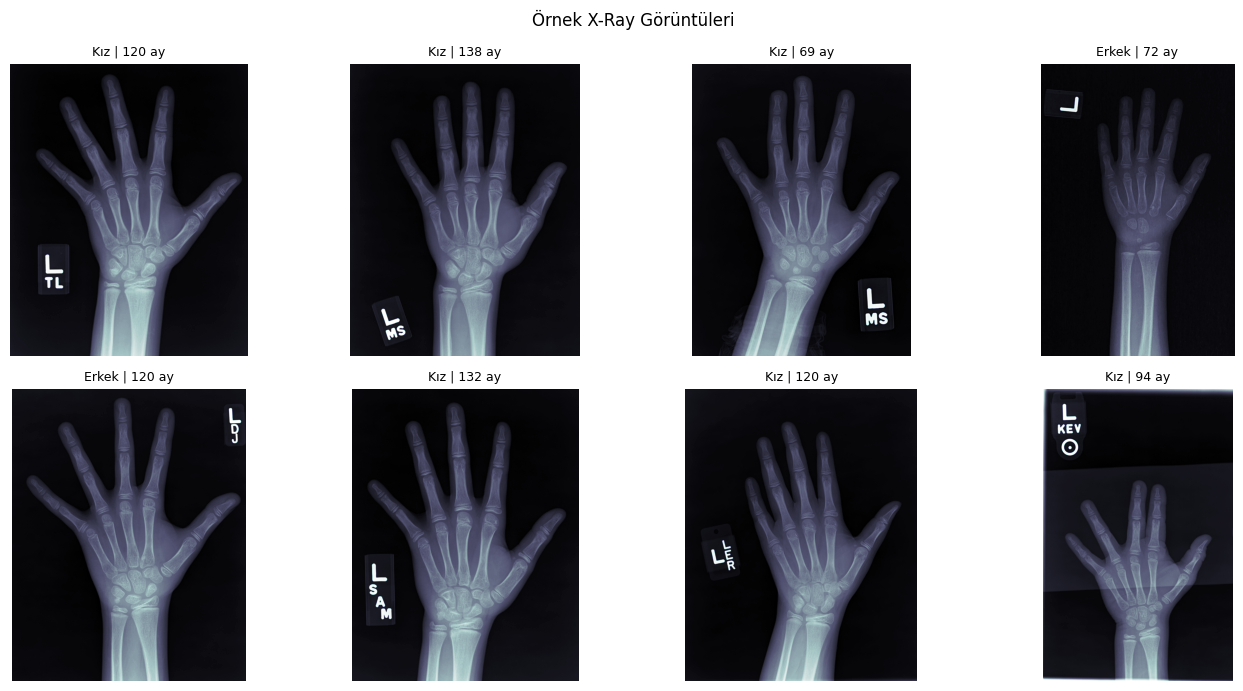

In [6]:
sample_rows = train_df.sample(min(8, len(train_df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    try:
        img = Image.open(row["img_path"]).convert("L")
        gender_str = "Erkek" if row[GENDER_COL] in [True, 1] else "Kız"
        ax.imshow(img, cmap="bone")
        ax.set_title(f"{gender_str} | {row[BONEAGE_COL]} ay", fontsize=9)
        ax.axis("off")
    except Exception:
        ax.axis("off")

plt.suptitle("Örnek X-Ray Görüntüleri", fontsize=12)
plt.tight_layout()
plt.show()

---
## Train / Validation / Test Ayrımı

In [7]:
train_df["boneage_bin"] = pd.cut(train_df[BONEAGE_COL], bins=10, labels=False)

n = len(train_df)
stratify_col = train_df["boneage_bin"] if n >= 200 else None

df_train_full, df_test = train_test_split(
    train_df, test_size=0.15,
    stratify=stratify_col, random_state=RANDOM_STATE
)

stratify_val = df_train_full["boneage_bin"] if n >= 200 else None

df_train, df_val = train_test_split(
    df_train_full, test_size=0.15 / 0.85,
    stratify=stratify_val, random_state=RANDOM_STATE
)

print(f"Train      : {len(df_train):>4} kayıt")
print(f"Validation : {len(df_val):>4} kayıt")
print(f"Test       : {len(df_test):>4} kayıt")
print(f"Stratified : {'Evet' if n >= 200 else 'Hayır (küçük örneklem)'}")

Train      :   34 kayıt
Validation :    8 kayıt
Test       :    8 kayıt
Stratified : Hayır (küçük örneklem)


---
## Görüntü Pipeline

In [8]:
def load_and_preprocess_image(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def build_dataset(df, batch_size=BATCH_SIZE, augment=False, shuffle=True):
    paths  = df["img_path"].values
    labels = df[BONEAGE_COL].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_STATE)
    ds = ds.map(lambda p, y: (load_and_preprocess_image(p), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(df_train, augment=True,  shuffle=True)
val_ds   = build_dataset(df_val,   augment=False, shuffle=False)
test_ds  = build_dataset(df_test,  augment=False, shuffle=False)

print(f"Train batches      : {len(train_ds)}")
print(f"Validation batches : {len(val_ds)}")
print(f"Test batches       : {len(test_ds)}")

Train batches      : 3
Validation batches : 1
Test batches       : 1


---
## Model Fonksiyonları

3 model: SimpleCNN, MobileNetV2, EfficientNetB0

In [9]:
def build_simple_cnn(input_shape=(*IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation="linear")(x)
    return keras.Model(inputs, output, name="SimpleCNN")

def build_transfer_model(base_class, model_name, input_shape=(*IMG_SIZE, 3)):
    base = base_class(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation="linear")(x)
    return keras.Model(inputs, output, name=model_name)

MODEL_REGISTRY = [
    ("SimpleCNN",      lambda: build_simple_cnn()),
    ("MobileNetV2",    lambda: build_transfer_model(MobileNetV2,   "MobileNetV2")),
    ("EfficientNetB0", lambda: build_transfer_model(EfficientNetB0, "EfficientNetB0")),
]

print(f"{len(MODEL_REGISTRY)} model kayıtlı:")
for name, _ in MODEL_REGISTRY:
    print(f"  → {name}")

3 model kayıtlı:
  → SimpleCNN
  → MobileNetV2
  → EfficientNetB0


In [10]:
def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=3,
            restore_best_weights=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, min_lr=1e-7, verbose=0
        )
    ]

def train_model(model, train_ds, val_ds):
    model.compile(optimizer=Adam(1e-3), loss="mae", metrics=["mae"])
    start = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS, callbacks=get_callbacks(), verbose=1
    )
    return history, round(time.time() - start, 1)

def evaluate_model(model, test_ds, df_test):
    y_pred = model.predict(test_ds, verbose=0).flatten()
    y_true = df_test[BONEAGE_COL].values.astype("float32")
    return {
        "y_true" : y_true,
        "y_pred" : y_pred,
        "MAE"    : round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE"   : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2"     : round(r2_score(y_true, y_pred), 4)
    }

print("Fonksiyonlar hazır.")

Fonksiyonlar hazır.


---
## Eğitim

In [11]:
all_histories   = {}
all_results     = {}
all_times       = {}
all_params      = {}

for model_name, model_fn in MODEL_REGISTRY:
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")

    model = model_fn()
    all_params[model_name] = model.count_params()

    history, elapsed = train_model(model, train_ds, val_ds)
    results = evaluate_model(model, test_ds, df_test)

    all_histories[model_name] = history
    all_results[model_name]   = results
    all_times[model_name]     = elapsed

    print(f"  MAE  : {results['MAE']} ay")
    print(f"  RMSE : {results['RMSE']} ay")
    print(f"  R²   : {results['R2']}")
    print(f"  Süre : {elapsed} sn")

    keras.backend.clear_session()


  SimpleCNN
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 116.1164 - mae: 116.1164 - val_loss: 119.9764 - val_mae: 119.9764 - learning_rate: 0.0010
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 115.3031 - mae: 115.3031 - val_loss: 119.2372 - val_mae: 119.2372 - learning_rate: 0.0010
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 112.3904 - mae: 112.3904 - val_loss: 117.2387 - val_mae: 117.2387 - learning_rate: 0.0010
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 109.5686 - mae: 109.5686 - val_loss: 112.4307 - val_mae: 112.4307 - learning_rate: 0.0010
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 104.5711 - mae: 104.5711 - val_loss: 102.3934 - val_mae: 102.3934 - learning_rate: 0.0010
  MAE  : 93.05 ay
  RMSE : 96.14 ay
  R²   : -14.0264
  Süre : 2.2 sn

  MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - loss: 113.8848 - mae: 113.8848 - val_loss: 109.4326 - val_mae: 109.4326 

---
## Eğitim Grafikleri

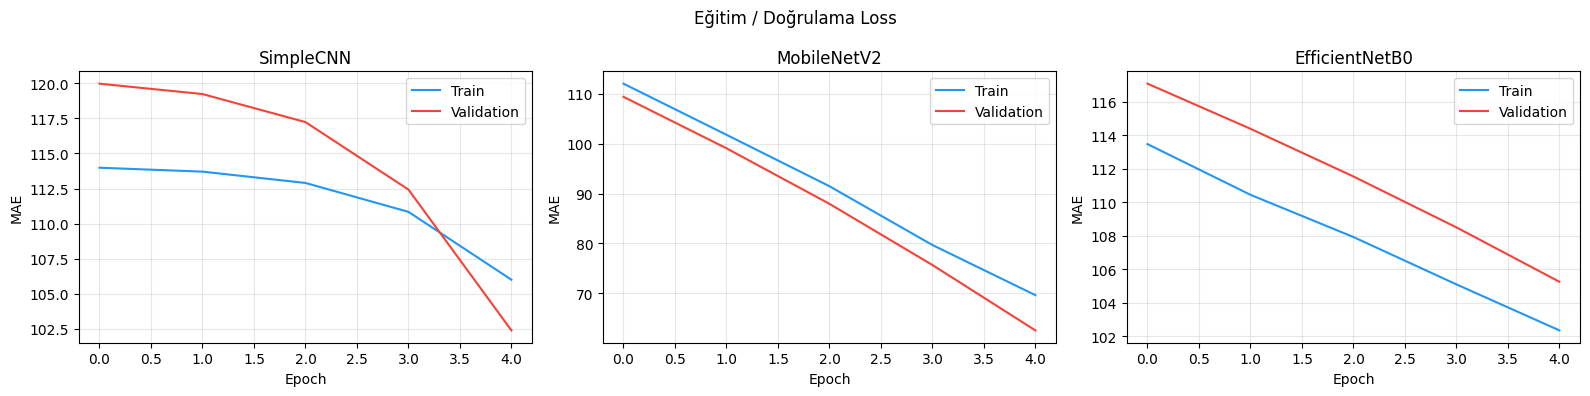

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, history) in zip(axes, all_histories.items()):
    ax.plot(history.history["loss"],     label="Train",      color="#2196F3")
    ax.plot(history.history["val_loss"], label="Validation", color="#F44336")
    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Eğitim / Doğrulama Loss", fontsize=12)
plt.tight_layout()
plt.show()

---
## Benchmark Tablosu

In [13]:
benchmark_df = pd.DataFrame([
    {
        "Model"            : name,
        "MAE (ay)"         : all_results[name]["MAE"],
        "RMSE (ay)"        : all_results[name]["RMSE"],
        "R²"               : all_results[name]["R2"],
        "Eğitim Süresi (s)": all_times[name],
        "Parametre Sayısı" : all_params[name]
    }
    for name in all_results
]).sort_values("MAE (ay)").reset_index(drop=True)

BEST_MODEL_NAME = benchmark_df.iloc[0]["Model"]

print(benchmark_df.to_string(index=False))
print(f"\n🏆 En iyi model (test): {BEST_MODEL_NAME}")
print("⚠️  50 görüntüyle eğitildiği için bu sıralama gerçekçi değildir.")

         Model  MAE (ay)  RMSE (ay)       R²  Eğitim Süresi (s)  Parametre Sayısı
   MobileNetV2     49.15      55.80  -4.0619                4.3           2422081
     SimpleCNN     93.05      96.14 -14.0264                2.2            109889
EfficientNetB0     93.12      96.36 -14.0960                7.4           4213668

🏆 En iyi model (test): MobileNetV2
⚠️  50 görüntüyle eğitildiği için bu sıralama gerçekçi değildir.


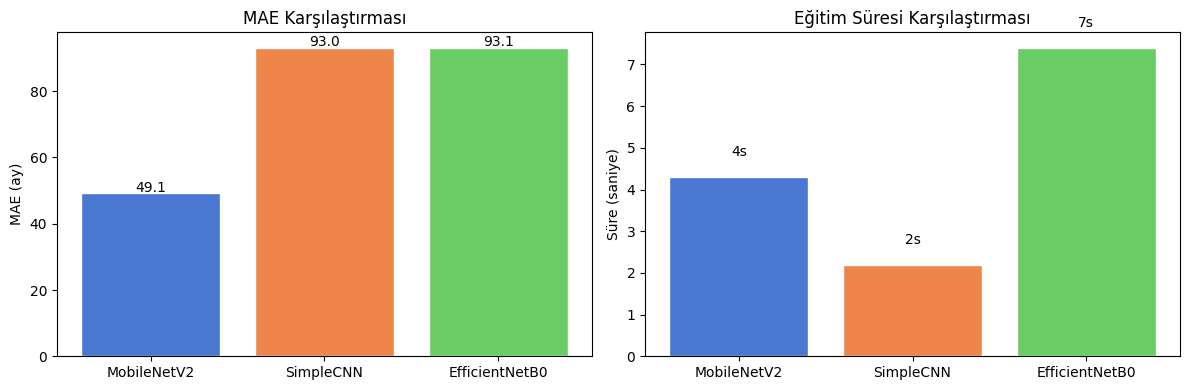

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = sns.color_palette("muted", len(benchmark_df))

bars = axes[0].bar(benchmark_df["Model"], benchmark_df["MAE (ay)"], color=colors, edgecolor="white")
for bar, val in zip(bars, benchmark_df["MAE (ay)"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}", ha="center", fontsize=10)
axes[0].set_title("MAE Karşılaştırması")
axes[0].set_ylabel("MAE (ay)")

bars2 = axes[1].bar(benchmark_df["Model"], benchmark_df["Eğitim Süresi (s)"], color=colors, edgecolor="white")
for bar, val in zip(bars2, benchmark_df["Eğitim Süresi (s)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.0f}s", ha="center", fontsize=10)
axes[1].set_title("Eğitim Süresi Karşılaştırması")
axes[1].set_ylabel("Süre (saniye)")

plt.tight_layout()
plt.show()

---
## Confusion Matrix (Gelişim Sapması)

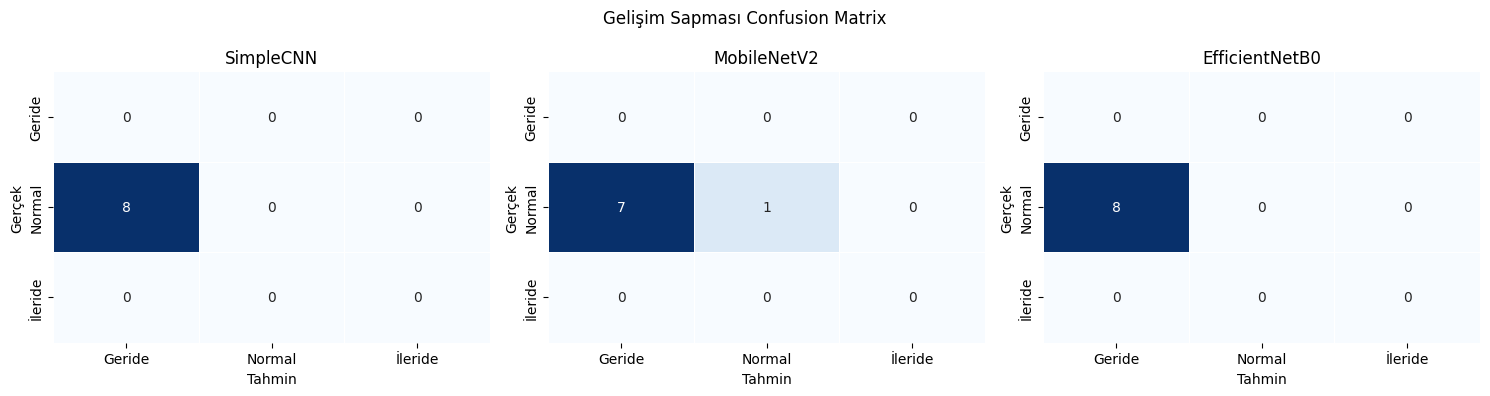

In [15]:
def categorize_development(y_true, y_pred):
    yuzde_sapma = (y_pred - y_true) / y_true * 100
    return pd.cut(yuzde_sapma,
                  bins=[-np.inf, -10, 10, np.inf],
                  labels=["Geride", "Normal", "İleride"])

class_labels = ["Geride", "Normal", "İleride"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, results) in zip(axes, all_results.items()):
    y_true = results["y_true"]
    y_pred = results["y_pred"]
    cats_true = categorize_development(y_true, y_true)
    cats_pred = categorize_development(y_true, y_pred)
    cm = confusion_matrix(cats_true, cats_pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f"{model_name}")
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")

plt.suptitle("Gelişim Sapması Confusion Matrix", fontsize=12)
plt.tight_layout()
plt.show()

---
## En İyi Model — Scatter ve Hata Dağılımı

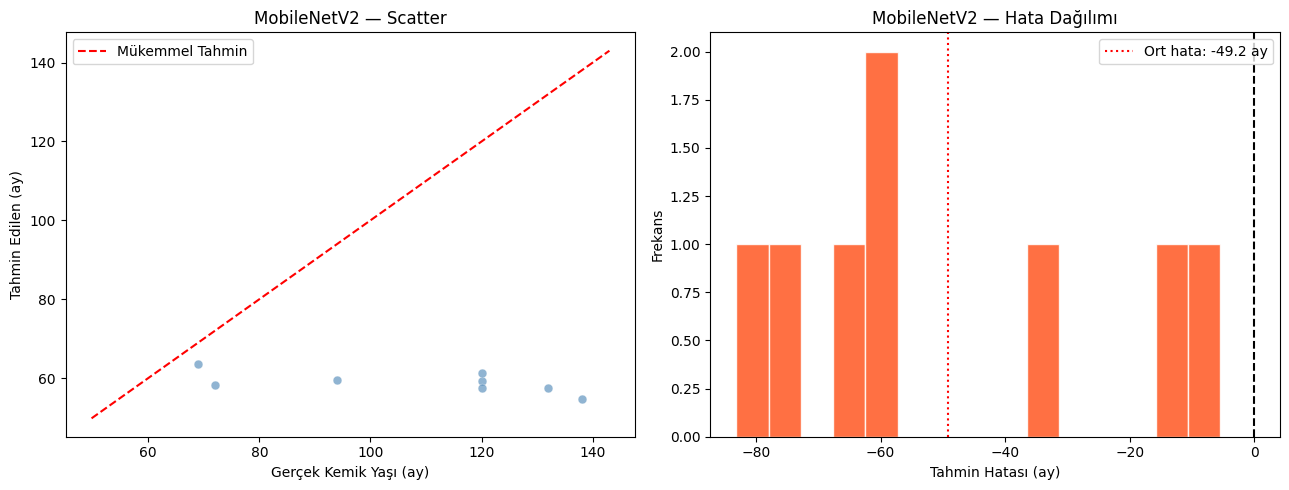

In [16]:
best = all_results[BEST_MODEL_NAME]
y_true = best["y_true"]
y_pred = best["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_true, y_pred, alpha=0.6, s=40, color="steelblue", edgecolors="white", linewidths=0.4)
lim = [min(y_true.min(), y_pred.min()) - 5, max(y_true.max(), y_pred.max()) + 5]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Mükemmel Tahmin")
axes[0].set_xlabel("Gerçek Kemik Yaşı (ay)")
axes[0].set_ylabel("Tahmin Edilen (ay)")
axes[0].set_title(f"{BEST_MODEL_NAME} — Scatter")
axes[0].legend()

errors = y_pred - y_true
axes[1].hist(errors, bins=15, color="#FF5722", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", lw=1.5)
axes[1].axvline(errors.mean(), color="red", linestyle=":", lw=1.5,
                label=f"Ort hata: {errors.mean():.1f} ay")
axes[1].set_xlabel("Tahmin Hatası (ay)")
axes[1].set_ylabel("Frekans")
axes[1].set_title(f"{BEST_MODEL_NAME} — Hata Dağılımı")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Gelişim Sapması Analizi — Örnek Vakalar

In [17]:
def interpret_development(gercek_yas_ay, tahmini_kemik_yasi_ay):
    sapma = tahmini_kemik_yasi_ay - gercek_yas_ay
    yuzde_sapma = sapma / gercek_yas_ay * 100
    if yuzde_sapma < -10:
        kategori = "🔴 Geride"
        yorum = "Kemik gelişimi akranlarına göre geridedir."
    elif yuzde_sapma > 10:
        kategori = "🟡 İleride"
        yorum = "Kemik gelişimi akranlarına göre ileridedir."
    else:
        kategori = "🟢 Normal"
        yorum = "Kemik gelişimi akranlarına göre normaldir."
    return {
        "Gerçek Yaş (ay)"         : int(gercek_yas_ay),
        "Tahmini Kemik Yaşı (ay)" : round(float(tahmini_kemik_yasi_ay), 1),
        "Sapma (ay)"              : round(float(sapma), 1),
        "Yüzde Sapma (%)"         : round(float(yuzde_sapma), 1),
        "Kategori"                : kategori,
        "Yorum"                   : yorum
    }

n_samples = min(8, len(y_true))
idx = np.random.choice(len(y_true), size=n_samples, replace=False)
example_df = pd.DataFrame([interpret_development(y_true[i], y_pred[i]) for i in idx])
pd.set_option("display.max_colwidth", None)
example_df

,Gerçek Yaş (ay),Tahmini Kemik Yaşı (ay),Sapma (ay),Yüzde Sapma (%),Kategori,Yorum
0,132,57.4,-74.6,-56.5,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
1,120,61.4,-58.6,-48.8,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
2,72,58.1,-13.9,-19.3,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
3,138,54.8,-83.2,-60.3,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
4,69,63.6,-5.4,-7.8,🟢 Normal,Kemik gelişimi akranlarına göre normaldir.
5,120,59.3,-60.7,-50.6,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
6,94,59.5,-34.5,-36.7,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.
7,120,57.5,-62.5,-52.1,🔴 Geride,Kemik gelişimi akranlarına göre geridedir.


---
## Özet

> ⚠️ Bu notebook yalnızca pipeline testine yöneliktir. Hiçbir dosya diske yazılmamıştır.

In [18]:
print("=" * 55)
print("  TEST SONUÇLARI")
print("=" * 55)
print(f"  Kullanılan görüntü : {len(train_df)}")
print(f"  Max epoch          : {EPOCHS}")
print(f"  Görüntü boyutu     : {IMG_SIZE}")
print()
print(benchmark_df[["Model","MAE (ay)","RMSE (ay)","R²","Eğitim Süresi (s)"]].to_string(index=False))
print()
print(f"  En iyi model : {BEST_MODEL_NAME}")
print()
print("  ✅ Pipeline çalışıyor")
print("  ✅ Hiçbir dosya diske yazılmadı")
print("  ✅ Asıl notebook aynen korunuyor")

  TEST SONUÇLARI
  Kullanılan görüntü : 50
  Max epoch          : 5
  Görüntü boyutu     : (128, 128)

         Model  MAE (ay)  RMSE (ay)       R²  Eğitim Süresi (s)
   MobileNetV2     49.15      55.80  -4.0619                4.3
     SimpleCNN     93.05      96.14 -14.0264                2.2
EfficientNetB0     93.12      96.36 -14.0960                7.4

  En iyi model : MobileNetV2

  ✅ Pipeline çalışıyor
  ✅ Hiçbir dosya diske yazılmadı
  ✅ Asıl notebook aynen korunuyor
